# **Face Recognition with SFace**

## **Objectives:**
1. Turn notebook 30's YuNet face *detections* into 128-d embeddings with `cv2.FaceRecognizerSF` (SFace)
2. Build a full pairwise similarity matrix across several captures of two different people and see whether it actually separates "same person" from "different person"
3. Check that separation against OpenCV's own published match threshold, not just eyeballed

> **Assets.** `assets/models/face_recognition_sface_2021dec.onnx` is the SFace embedding model from OpenCV's own model zoo ([opencv/opencv_zoo](https://github.com/opencv/opencv_zoo/tree/main/models/face_recognition_sface), Apache 2.0 — that model directory carries its own explicit `LICENSE` file, same as notebook 30's YuNet). Reuses notebook 30's `face_detection_yunet_2023mar.onnx` to find the face box before SFace converts it into an embedding — detection and recognition are two separate models doing two separate jobs, chained together the way a real face-ID pipeline actually works.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Detection vs. recognition — two different questions**

Notebook 30 answered *"is there a face here, and where?"* — a box (plus landmarks). This notebook answers a completely different question: *"is this face the same **person** as that other face?"* SFace answers it by mapping an aligned face crop to a 128-number vector — an embedding — such that two photos of the same person land close together in that 128-d space, and two photos of different people land far apart. Recognition is nothing more than measuring that distance.

In [2]:
detector = cv2.FaceDetectorYN_create(
    'assets/models/face_detection_yunet_2023mar.onnx', '', (0, 0),
    score_threshold=0.6, nms_threshold=0.3, top_k=5000,
)
recognizer = cv2.FaceRecognizerSF_create('assets/models/face_recognition_sface_2021dec.onnx', '')

def embed(image):
    """Detect the first face in `image`, align it, and return its 128-d SFace embedding."""
    detector.setInputSize((image.shape[1], image.shape[0]))
    _, faces = detector.detect(image)
    if faces is None:
        return None
    aligned = recognizer.alignCrop(image, faces[0])
    return recognizer.feature(aligned)

## **Building a small, honest identity set**

This repo's asset pack only has two clean single-portrait photos to work with — `lena.jpg` and `messi5.jpg` — so rather than pretend there are more real photos of the same people than there actually are, "different captures" of Lena are produced the honest way: real geometric/photometric transforms (rotation, brightening, blur), the exact same kind of pose and lighting variation a second real photo would introduce, and the same rotation-robustness angle notebook 30 already used for *detection*. If SFace embeddings are worth anything, all four Lena variants should cluster together and stay well clear of Messi — a single real photo of a second person is enough to prove separation.

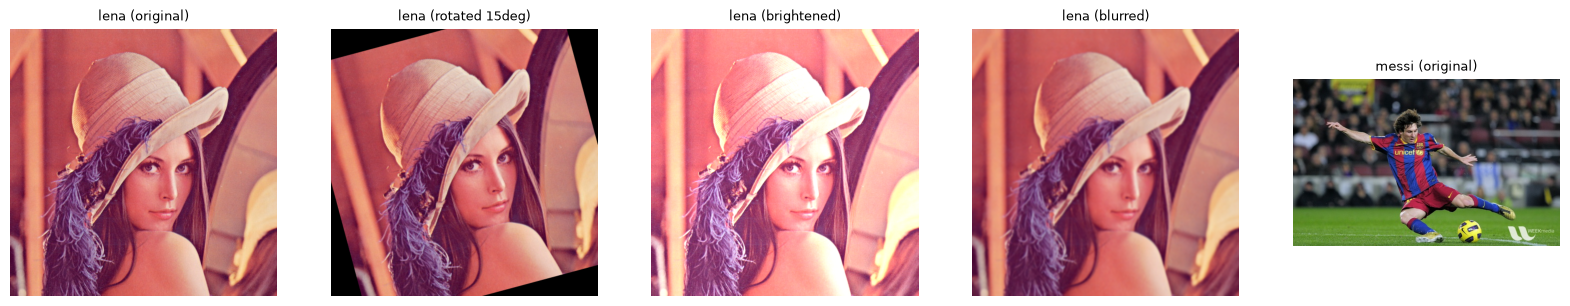

In [3]:
lena = cv2.imread('assets/images/lena.jpg')
messi = cv2.imread('assets/images/messi5.jpg')
h, w = lena.shape[:2]

M = cv2.getRotationMatrix2D((w / 2, h / 2), 15, 1.0)
lena_rotated = cv2.warpAffine(lena, M, (w, h))
lena_bright = cv2.convertScaleAbs(lena, alpha=1.25, beta=25)
lena_blurred = cv2.GaussianBlur(lena, (7, 7), 0)

captures = {
    'lena (original)': lena,
    'lena (rotated 15deg)': lena_rotated,
    'lena (brightened)': lena_bright,
    'lena (blurred)': lena_blurred,
    'messi (original)': messi,
}

fig, axes = plt.subplots(1, len(captures), figsize=(20, 4))
for ax, (name, im) in zip(axes, captures.items()):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.show()

## **The full pairwise similarity matrix**

Embed every capture, then compute cosine similarity for every pair. A well-behaved embedding space should show a clean block structure: high similarity within the four Lena captures, low similarity between any Lena capture and Messi.

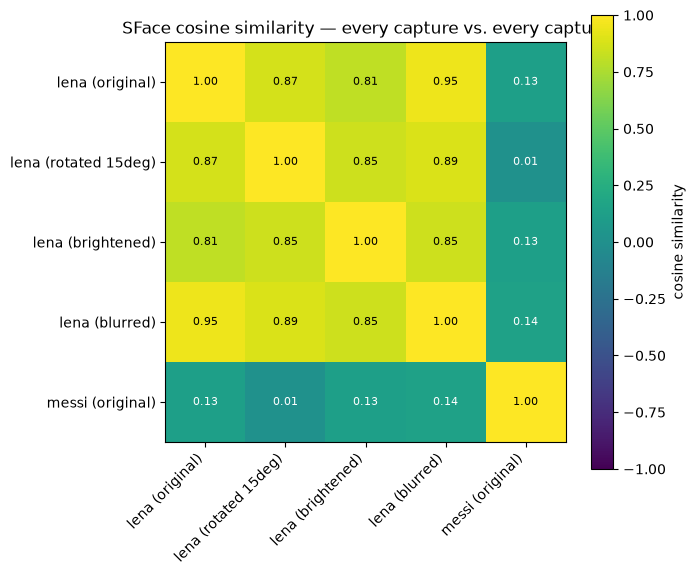

In [4]:
names = list(captures.keys())
features = {name: embed(im) for name, im in captures.items()}
missing = [n for n, f in features.items() if f is None]
if missing:
    print(f'No face detected for: {missing}')

n = len(names)
sim = np.zeros((n, n))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        sim[i, j] = recognizer.match(features[a], features[b], cv2.FaceRecognizerSF_FR_COSINE)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim, cmap='viridis', vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(names)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                color='white' if sim[i, j] < 0.5 else 'black', fontsize=8)
ax.set_title('SFace cosine similarity — every capture vs. every capture')
fig.colorbar(im, label='cosine similarity')
plt.tight_layout()
plt.show()

## **Calling it: match or no match?**

A similarity number alone isn't a decision — it needs a threshold. OpenCV's own SFace demo script ships published reference thresholds: **cosine similarity ≥ 0.363** (or, equivalently, **L2-normalized distance ≤ 1.128**) counts as the same person. Applying that threshold turns the matrix above into an actual verification call for every pair, checked against the ground truth we already know (four Lena captures, one Messi capture).

In [5]:
COSINE_MATCH_THRESHOLD = 0.363

correct = 0
total = 0
for i, a in enumerate(names):
    for j, b in enumerate(names):
        if j <= i:
            continue
        same_person_truth = a.startswith('lena') and b.startswith('lena')
        predicted_match = sim[i, j] >= COSINE_MATCH_THRESHOLD
        correct += predicted_match == same_person_truth
        total += 1
        verdict = 'MATCH' if predicted_match else 'no match'
        flag = 'OK' if predicted_match == same_person_truth else 'WRONG'
        print(f'[{flag:>5}] {a:22s} vs {b:22s}  cos={sim[i, j]:.3f}  -> {verdict}')

print(f'\n{correct}/{total} pairwise calls correct at threshold {COSINE_MATCH_THRESHOLD}')

[   OK] lena (original)        vs lena (rotated 15deg)    cos=0.874  -> MATCH
[   OK] lena (original)        vs lena (brightened)       cos=0.811  -> MATCH
[   OK] lena (original)        vs lena (blurred)          cos=0.946  -> MATCH
[   OK] lena (original)        vs messi (original)        cos=0.130  -> no match
[   OK] lena (rotated 15deg)   vs lena (brightened)       cos=0.848  -> MATCH
[   OK] lena (rotated 15deg)   vs lena (blurred)          cos=0.886  -> MATCH
[   OK] lena (rotated 15deg)   vs messi (original)        cos=0.015  -> no match
[   OK] lena (brightened)      vs lena (blurred)          cos=0.850  -> MATCH
[   OK] lena (brightened)      vs messi (original)        cos=0.130  -> no match
[   OK] lena (blurred)         vs messi (original)        cos=0.144  -> no match

10/10 pairwise calls correct at threshold 0.363


## **Embedding extraction speed**

Detection (YuNet) and recognition (SFace) are two separate forward passes chained together — worth timing each stage separately, since a real pipeline (e.g. checking a face against a database of thousands of stored embeddings) runs detection once per frame but the *match* step is just a dot product, cheap enough to do thousands of times a second once the embedding exists.

In [6]:
import time

N = 20
detector.setInputSize((lena.shape[1], lena.shape[0]))
t0 = time.perf_counter()
for _ in range(N):
    detector.detect(lena)
t1 = time.perf_counter()
_, faces = detector.detect(lena)
aligned = recognizer.alignCrop(lena, faces[0])
for _ in range(N):
    recognizer.feature(aligned)
t2 = time.perf_counter()
f1, f2 = features['lena (original)'], features['messi (original)']
for _ in range(N * 50):
    recognizer.match(f1, f2, cv2.FaceRecognizerSF_FR_COSINE)
t3 = time.perf_counter()

print(f'YuNet detect:     {(t1 - t0) / N * 1000:.2f} ms/image')
print(f'SFace embed:       {(t2 - t1) / N * 1000:.2f} ms/face')
print(f'SFace match:        {(t3 - t2) / (N * 50) * 1000:.4f} ms/pair')

YuNet detect:     4.67 ms/image
SFace embed:       6.06 ms/face
SFace match:        0.0007 ms/pair


### Where to go from here

- Swap the cosine threshold sweep from a single cutoff to a ROC-style sweep across many thresholds and plot precision/recall — the same tradeoff notebook 30's `score_threshold` sweep suggestion explored, one level up the pipeline.
- Use `cv2.FaceRecognizerSF_FR_NORM_L2` instead of cosine (threshold ≈ 1.128) and check whether it agrees with every cosine-based call above — the two metrics should almost always agree, since both come from the same normalized embedding.
- Feed a webcam stream through `embed()` frame-by-frame and compare live against one stored reference embedding — that's the entire mechanism behind a phone's face-unlock, minus the anti-spoofing liveness check.